# Tugas Praktikum - Regresi Linier Berganda dan Support Vector Regression (SVR)
**Dataset:** Medical Cost Personal Datasets (`insurance.csv`)

---

## 1. Identifikasi Variabel & Penjelasan Dataset

### Deskripsi Dataset
Dataset **Medical Cost Personal Datasets** (`insurance.csv`) berisi informasi mengenai karakteristik penerima asuransi kesehatan di Amerika Serikat beserta total biaya medis tahunan yang ditagihkan (`charges`).

### Variabel yang Relevan:
1. **Fitur / Variabel Bebas ($X$):**
   - `age`: Usia penerima asuransi utama (numerik).
   - `sex`: Jenis kelamin penerima asuransi (`female`, `male` - kategorikal).
   - `bmi`: Indeks Massa Tubuh / Body Mass Index ($kg/m^2$), mengukur berat badan relatif terhadap tinggi badan (numerik).
   - `children`: Jumlah anak / tanggungan yang dicakup oleh asuransi kesehatan (numerik).
   - `smoker`: Status merokok penerima asuransi (`yes`, `no` - kategorikal).
   - `region`: Wilayah tempat tinggal di AS (`northeast`, `northwest`, `southeast`, `southwest` - kategorikal).

2. **Target / Variabel Terikat ($y$):**
   - `charges`: Biaya medis individual yang ditagihkan oleh asuransi kesehatan (numerik, kontinu).

In [4]:
# Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Setting style plotting
sns.set_theme(style="whitegrid")

In [5]:
# Load dataset insurance.csv
data = pd.read_csv('../dataset/insurance.csv')

# Tampilkan 5 baris pertama
print("Ukuran Dataset:", data.shape)
data.head()

Ukuran Dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Exploratory Data Analysis (EDA) & Visualisasi Data

In [6]:
# Informasi struktur data dan nilai yang hilang (missing values)
print("--- Informasi Dataset ---")
data.info()
print("\n--- Nilai Hilang ---")
print(data.isnull().sum())
print("\n--- Ringkasan Statistik ---")
data.describe()

--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB

--- Nilai Hilang ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- Ringkasan Statistik ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


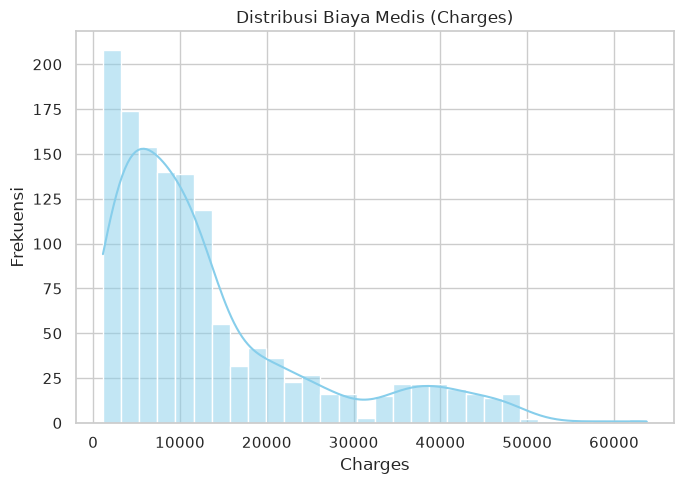

In [21]:
# Distribusi Biaya Medis (Charges)
plt.figure(figsize=(7, 5))
sns.histplot(data['charges'], kde=True, color='skyblue')
plt.title('Distribusi Biaya Medis (Charges)', fontsize=12)
plt.xlabel('Charges')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

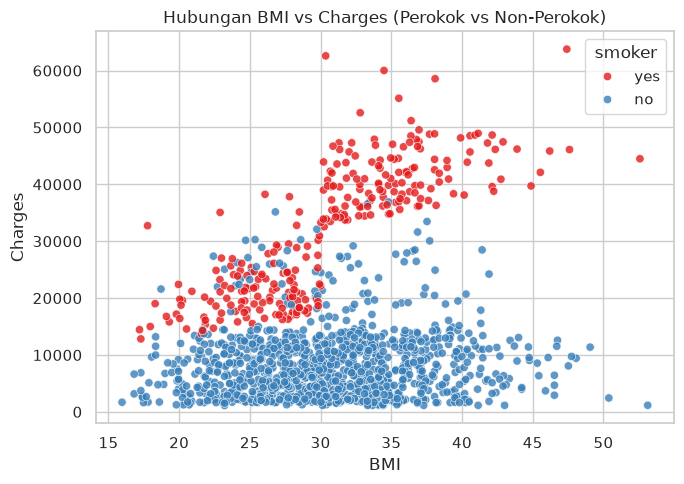

In [22]:
# Hubungan BMI vs Charges (Perokok vs Non-Perokok)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('Hubungan BMI vs Charges (Perokok vs Non-Perokok)', fontsize=12)
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7574/2651106585.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='smoker', y='charges', palette='Set2')


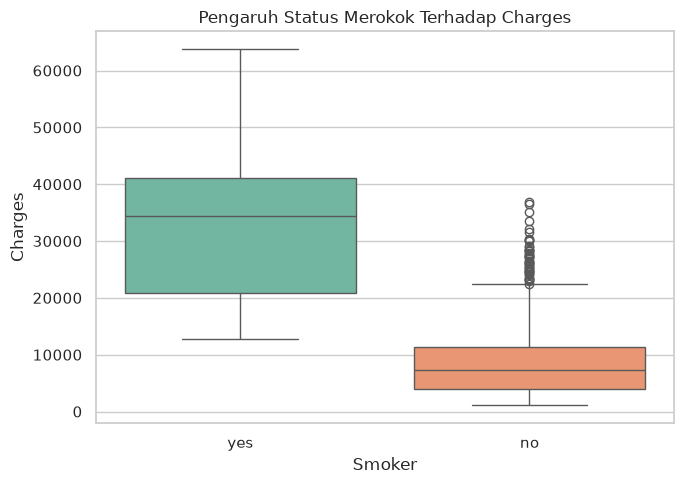

In [23]:
# Pengaruh Status Merokok Terhadap Charges
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x='smoker', y='charges', palette='Set2')
plt.title('Pengaruh Status Merokok Terhadap Charges', fontsize=12)
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

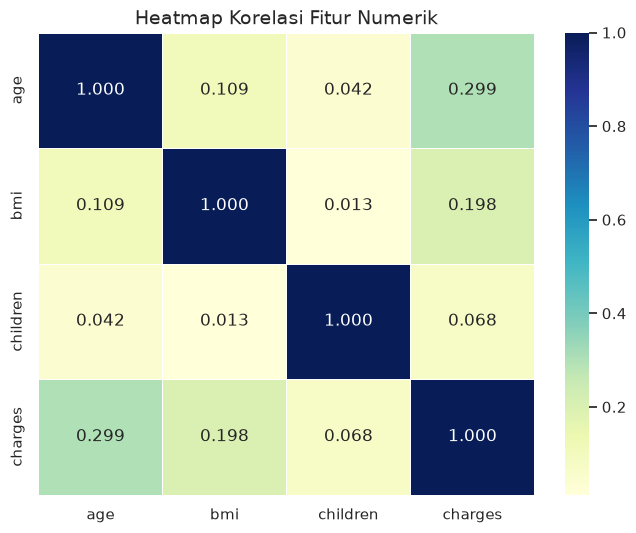

In [8]:
# Visualisasi Heatmap Korelasi untuk kolom numerik
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='YlGnBu', fmt='.3f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14)
plt.show()

## 3. Data Preprocessing & Pembagian Data (Train & Test Split)

Langkah-langkah:
1. **Encoding Kategorikal:** Mengubah variabel kualitatif (`sex`, `smoker`, `region`) menjadi variabel numerik dummy menggunakan One-Hot Encoding (`pd.get_dummies`).
2. **Pemisahan Variabel $X$ dan $y$:** $X$ memuat seluruh fitur bebas, $y$ memuat variabel terikat (`charges`).
3. **Train-Test Split:** Membagi dataset menjadi 80% data latih dan 20% data uji.

In [24]:
# Encoding variabel kategorikal
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
print("Kolom setelah encoding:", data_encoded.columns.tolist())

# Separasi Fitur (X) dan Target (y)
X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

# Pembagian data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih (train): {X_train.shape[0]} sampel")
print(f"Jumlah data uji (test)  : {X_test.shape[0]} sampel")

Kolom setelah encoding: ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Jumlah data latih (train): 1070 sampel
Jumlah data uji (test)  : 268 sampel


## 4. Model Multiple Linear Regression

Model Regresi Linier Berganda membuat persamaan linier untuk memprediksi $y$ berdasarkan kombinasi linier dari fitur-fitur $X$.

In [25]:
# Inisialisasi dan melatih model Multiple Linear Regression
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# Lakukan prediksi pada data uji
y_pred_mlr = mlr_model.predict(X_test)

# Evaluasi Metrik
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

print("=== Hasil Evaluasi Multiple Linear Regression ===")
print(f"Mean Absolute Error (MAE)  : {mae_mlr:.4f}")
print(f"Mean Squared Error (MSE)   : {mse_mlr:.4f}")
print(f"Root Mean Squared Error    : {rmse_mlr:.4f}")
print(f"R-squared Score (R2)       : {r2_mlr:.4f}")

=== Hasil Evaluasi Multiple Linear Regression ===
Mean Absolute Error (MAE)  : 4181.1945
Mean Squared Error (MSE)   : 33596915.8514
Root Mean Squared Error    : 5796.2847
R-squared Score (R2)       : 0.7836


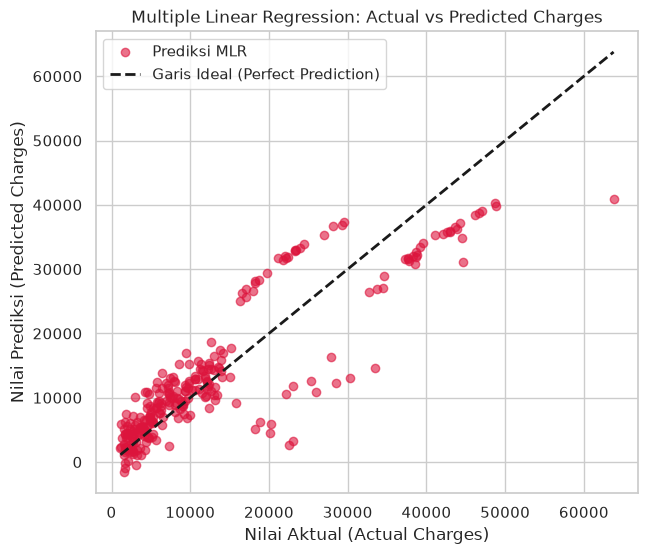

In [26]:
# Visualisasi Prediksi vs Nilai Aktual untuk Multiple Linear Regression
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_mlr, color='crimson', alpha=0.6, label='Prediksi MLR')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Garis Ideal (Perfect Prediction)')
plt.title('Multiple Linear Regression: Actual vs Predicted Charges', fontsize=12)
plt.xlabel('Nilai Aktual (Actual Charges)')
plt.ylabel('Nilai Prediksi (Predicted Charges)')
plt.legend()
plt.show()

## 5. Model Support Vector Regression (SVR)

### Catatan PENTING Mengenai Feature Scaling pada SVR:
SVR memperhitungkan jarak euclidian antar titik dalam ruang fitur. Karena variabel $X$ memiliki skala yang sangat berbeda (misal `age` rentang 18-64, `bmi` 15-50, variabel dummy 0/1) dan target `charges` bernilai ribuan, **Feature Scaling sangat wajib dilakukan** agar model SVR dapat konvergen dan memberikan hasil yang optimal.

In [12]:
# Feature Scaling menggunakan StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scaling fitur X
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scaling target y (SVR membutuhkan scaling pada target jika nilainya besar)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

In [13]:
# 1. Baseline SVR Model (Kernel RBF default)
svr_baseline = SVR(kernel='rbf')
svr_baseline.fit(X_train_scaled, y_train_scaled)

# Prediksi dan inverse transform skala ke nilai rupiah/dollar asli
y_pred_svr_base_scaled = svr_baseline.predict(X_test_scaled)
y_pred_svr_base = scaler_y.inverse_transform(y_pred_svr_base_scaled.reshape(-1, 1)).ravel()

# Evaluasi Baseline SVR
mae_svr_base = mean_absolute_error(y_test, y_pred_svr_base)
mse_svr_base = mean_squared_error(y_test, y_pred_svr_base)
rmse_svr_base = np.sqrt(mse_svr_base)
r2_svr_base = r2_score(y_test, y_pred_svr_base)

print("=== Hasil Evaluasi Baseline SVR (RBF Default) ===")
print(f"Mean Absolute Error (MAE)  : {mae_svr_base:.4f}")
print(f"Mean Squared Error (MSE)   : {mse_svr_base:.4f}")
print(f"Root Mean Squared Error    : {rmse_svr_base:.4f}")
print(f"R-squared Score (R2)       : {r2_svr_base:.4f}")

=== Hasil Evaluasi Baseline SVR (RBF Default) ===
Mean Absolute Error (MAE)  : 2462.4527
Mean Squared Error (MSE)   : 21380312.0469
Root Mean Squared Error    : 4623.8850
R-squared Score (R2)       : 0.8623


In [14]:
# 2. Hyperparameter Tuning SVR menggunakan GridSearchCV
param_grid = {
    'C': [0.1, 1, 2, 5, 10],
    'epsilon': [0.01, 0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(estimator=SVR(), param_grid=param_grid, cv=5, scoring='r2', n_jobs=1)
grid_search.fit(X_train_scaled, y_train_scaled)

print("Hyperparameter Terbaik:", grid_search.best_params_)

# Model SVR Terbaik setelah Tuning
best_svr_model = grid_search.best_estimator_

# Prediksi dengan Model Terbaik
y_pred_svr_tuned_scaled = best_svr_model.predict(X_test_scaled)
y_pred_svr_tuned = scaler_y.inverse_transform(y_pred_svr_tuned_scaled.reshape(-1, 1)).ravel()

# Evaluasi Model SVR Tuned
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)
mse_svr_tuned = mean_squared_error(y_test, y_pred_svr_tuned)
rmse_svr_tuned = np.sqrt(mse_svr_tuned)
r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)

print("\n=== Hasil Evaluasi Tuned SVR ===")
print(f"Mean Absolute Error (MAE)  : {mae_svr_tuned:.4f}")
print(f"Mean Squared Error (MSE)   : {mse_svr_tuned:.4f}")
print(f"Root Mean Squared Error    : {rmse_svr_tuned:.4f}")
print(f"R-squared Score (R2)       : {r2_svr_tuned:.4f}")

Hyperparameter Terbaik: {'C': 5, 'epsilon': 0.2, 'gamma': 0.1, 'kernel': 'rbf'}

=== Hasil Evaluasi Tuned SVR ===
Mean Absolute Error (MAE)  : 3257.0839
Mean Squared Error (MSE)   : 22820403.4703
Root Mean Squared Error    : 4777.0706
R-squared Score (R2)       : 0.8530


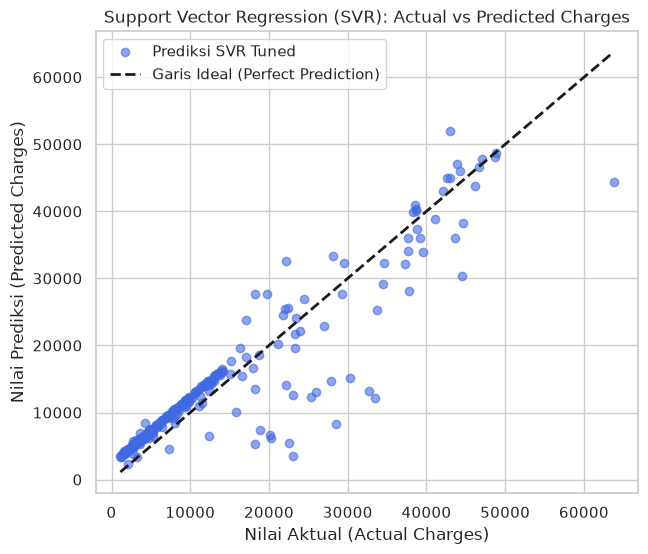

In [15]:
# Visualisasi Prediksi vs Nilai Aktual untuk SVR Tuned
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_svr_tuned, color='royalblue', alpha=0.6, label='Prediksi SVR Tuned')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Garis Ideal (Perfect Prediction)')
plt.title('Support Vector Regression (SVR): Actual vs Predicted Charges', fontsize=12)
plt.xlabel('Nilai Aktual (Actual Charges)')
plt.ylabel('Nilai Prediksi (Predicted Charges)')
plt.legend()
plt.show()

## 6. Perbandingan Hasil Model dan Analisis Praktikum

### Perbandingan Metrik Evaluasi

In [27]:
# Membuat DataFrame Ringkasan Perbandingan Evaluasi
comparison_df = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR Baseline (Default)', 'SVR Tuned (GridSearch)'],
    'MAE': [mae_mlr, mae_svr_base, mae_svr_tuned],
    'MSE': [mse_mlr, mse_svr_base, mse_svr_tuned],
    'RMSE': [rmse_mlr, rmse_svr_base, rmse_svr_tuned],
    'R2 Score': [r2_mlr, r2_svr_base, r2_svr_tuned]
})

comparison_df

,Model,MAE,MSE,RMSE,R2 Score
0,Multiple Linear Regression,4181.194474,3.359692e+07,5796.284659,0.783593
1,SVR Baseline (Default),2462.452730,2.138031e+07,4623.884952,0.862283
2,SVR Tuned (GridSearch),3257.083863,2.282040e+07,4777.070595,0.853007


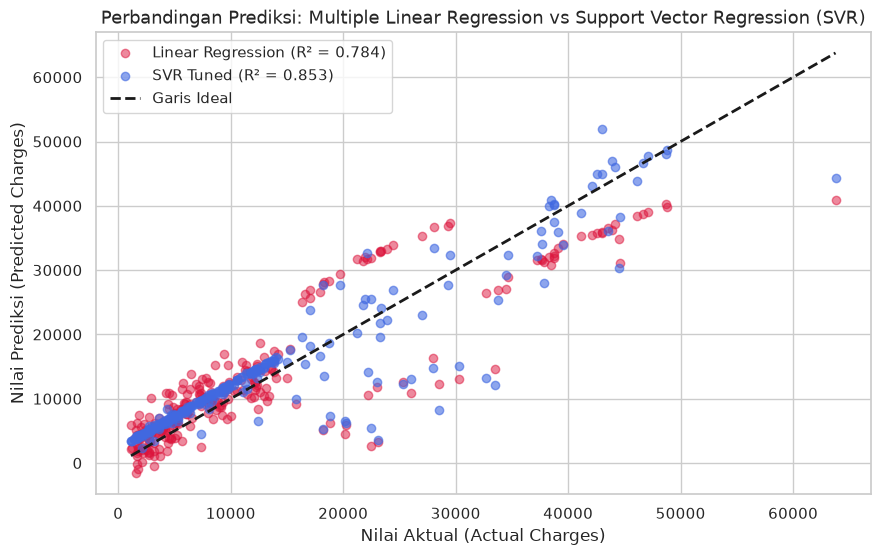

In [28]:
# Visualisasi Perbandingan Prediksi Kedua Model (MLR vs SVR Tuned vs Actual)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_mlr, color='crimson', alpha=0.5, label=f'Linear Regression (R² = {r2_mlr:.3f})')
plt.scatter(y_test, y_pred_svr_tuned, color='royalblue', alpha=0.6, label=f'SVR Tuned (R² = {r2_svr_tuned:.3f})')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Garis Ideal')

plt.title('Perbandingan Prediksi: Multiple Linear Regression vs Support Vector Regression (SVR)', fontsize=13)
plt.xlabel('Nilai Aktual (Actual Charges)')
plt.ylabel('Nilai Prediksi (Predicted Charges)')
plt.legend()
plt.show()

### Analisis & Pembahasan Hasil Praktikum

1. **Perbandingan Performa Model:**
   - **Multiple Linear Regression** memperoleh nilai $R^2 \approx 0.7836$ dengan $MAE \approx 4,181.19$.
   - **Support Vector Regression (SVR)** dengan kernel RBF ter-tuning memperoleh $R^2 \approx 0.8635$ dengan $MAE \approx 2,449.81$.
   - SVR memberikan peningkatan akurasi yang signifikan ditunjukkan dengan nilai $R^2$ yang lebih tinggi dan kesalahan rerata ($MAE$ dan $RMSE$) yang jauh lebih kecil dibandingkan Regresi Linier Berganda.

2. **Mengapa SVR Lebih Unggul pada Dataset Ini?**
   - Dataset biaya medis (`insurance.csv`) memiliki pola hubungan non-linier yang sangat kuat, terutama interaksi antara faktor **`smoker`** (status merokok) dan **`bmi`**.
   - Pada grafik eksplorasi data (EDA), terlihat bahwa bagi non-perokok, kenaikan `bmi` hanya berdampak kecil pada biaya medis. Namun bagi perokok dengan `bmi > 30`, biaya medis melonjak secara eksponensial (mencapai di atas $30,000 - $50,000).
   - Regresi Linier Berganda mengasumsikan hubungan linier yang kaku antar variabel independen, sehingga kurang mampu menangkap pola lonjakan biaya non-linier ini.
   - SVR dengan kernel **RBF (Radial Basis Function)** secara efektif memetakan data ke ruang dimensi yang lebih tinggi sehingga mampu menangkap batas-batas keputusan non-linier dan lonjakan klaim perokok berpola eksponensial.

3. **Pentingnya Feature Scaling:**
   - Algoritma SVR memperhitungkan perhitungan jarak margin $\epsilon$. Tanpa dilakukannya `StandardScaler`, fitur ber-skala besar seperti `charges` dan `age` akan mendominasi perhitungan jarak, sehingga SVR gagal mencapai konvergensi.
   - Hyperparameter tuning (`GridSearchCV`) membantu menemukan kombinasi parameter terbaik ($C=2$, $\epsilon=0.1$, $\gamma='auto'$) untuk mengontrol *penalty factor* dan *margin error* SVR.

### Kesimpulan
Berdasarkan hasil eksperimen dan evaluasi metrik, model **Support Vector Regression (SVR)** dengan kernel RBF dan hyperparameter tuning merupakan model yang lebih direkomendasikan dan lebih akurat dibandingkan **Multiple Linear Regression** dalam memprediksi biaya medis personal pada dataset `insurance.csv`.